<a href="https://colab.research.google.com/github/ufukalp07/swps-developer-tools/blob/main/lab_09_ipynb_adl%C4%B1_not_defterinin_kopyas%C4%B1_adl%C4%B1_not_defterinin_kopyas%C4%B1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 9. Exploratory data analysis - exercises

All of the exercises are based on lecture (https://github.com/agazbrzezny/DAT-SWPS-2026/blob/main/statistics.ipynb) and examples presented there.

## Exercises

**Task 1**

Use the [Heart Disease](https://archive.ics.uci.edu/dataset/45/heart+disease) dataset, and then:
* 1.1 Check the data card to see which features are numerical and which are categorical. Check how the pandas library loads this data by default. If a categorical feature is marked as numerical in the table, change it to categorical (pandas has a `category` data type).
* 1.2 Check if there are any missing values in the dataset. If so, before proceeding with the next tasks, prepare a subset of the data that does not contain observations with missing values.

**Task 2**

For the dataset from Task 1, calculate and display:
* 2.1 The distribution of values in the `num` column (Target) – is the data balanced? Display it in a pie chart.
* 2.2 Basic descriptive statistics for each numerical feature (min, max, mean, median, standard deviation, and the 25th, 50th, and 75th percentiles).
* 2.3 The mode for each categorical feature.
* 2.4 Display the Pearson correlation matrix for each numerical feature in the dataset. Also display it on a heatmap using the seaborn library.
* 2.5 From the correlation matrix, display the names of the three features most correlated with the `age` feature (absolute correlation values, excluding the `age` feature itself from the results, which, as we know, will be correlated with itself to a degree of 1).

**Task 3**

Use the [Adult] dataset (https://archive.ics.uci.edu/dataset/2/adult) to complete the following instructions. In this dataset, also set the categorical types for the appropriate columns as described in the dataset documentation.

* 3.1 Perform a t-test for paired samples on the `capital-gain` feature values, assuming the following null hypothesis: the mean value of this feature for `race`=‘White’ is significantly higher than for the other `race` values. Accept or reject the null hypothesis.

* 3.2 Using an ANOVA test, check how statistically significant the difference in the mean value of the `capital-gain` feature is for each value of `race` separately. Report the `p-values` for this test. How should this result be interpreted?

**Task 4**

Perform a chi-square test on the values of the `capital-income` feature for two groups:
* people aged < 40
* people aged >= 40

Display the results of this test.

In [5]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

# safe fetch implementation
heart_disease = fetch_ucirepo(id=45)

# convert directly to standard pandas DataFrames
X_heart = pd.DataFrame(heart_disease.data.features)
y_heart = pd.DataFrame(heart_disease.data.targets)

# join features and targets cleanly before editing types
heart_df = pd.concat([X_heart, y_heart], axis=1)

print("Initial data types:")
print(heart_df.dtypes)

# fallback list of expected columns from the dataset documentation
expected_categorical = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal",
    "num",
]
expected_numerical = ["age", "trestbps", "chol", "thalach", "oldpeak"]

# safely map and cast only the columns that exist in the frame
for col in heart_df.columns:
    if col in expected_categorical:
        heart_df[col] = heart_df[col].astype("category")
    elif col in expected_numerical:
        heart_df[col] = pd.to_numeric(heart_df[col], errors="coerce")

print("\nData types after safe modification:")
print(heart_df.dtypes)

# calculate total missing entries across columns
print("\nMissing values breakdown:")
print(heart_df.isnull().sum())

# clear out rows containing any structural missing data points
heart_df_clean = heart_df.dropna().copy()
print(
    f"\nCleaning complete. Original rows: {len(heart_df)} -> Cleaned rows: {len(heart_df_clean)}"
)

Initial data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
num           int64
dtype: object

Data types after safe modification:
age            int64
sex         category
cp          category
trestbps       int64
chol           int64
fbs         category
restecg     category
thalach        int64
exang       category
oldpeak      float64
slope       category
ca          category
thal        category
num         category
dtype: object

Missing values breakdown:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

Cleaning complete. Original rows: 303 -> Cleaned rows: 297


Target distribution:
num
0    160
1     54
2     35
3     35
4     13
Name: count, dtype: int64


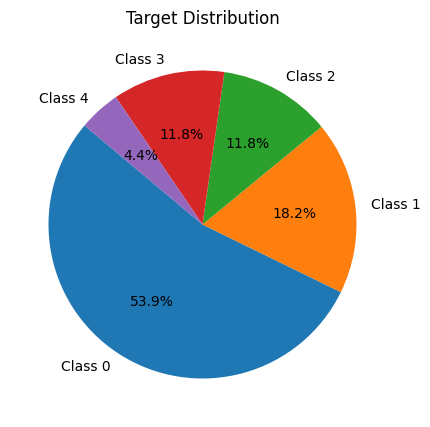


Numerical statistics:


NameError: name 'numerical_cols' is not defined

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

target_counts = heart_df_clean["num"].value_counts().sort_index()
print("Target distribution:")
print(target_counts)

plt.figure(figsize=(5, 5))
plt.pie(
    target_counts,
    labels=[f"Class {i}" for i in target_counts.index],
    autopct="%1.1f%%",
    startangle=140,
)
plt.title("Target Distribution")
plt.show()

print("\nNumerical statistics:")
print(heart_df_clean[numerical_cols].describe().T)

print("\nCategorical mode:")
print(heart_df_clean[categorical_cols].mode().iloc[0])

corr_matrix = heart_df_clean[numerical_cols].corr(method="pearson")
print("\nCorrelation Matrix:")
print(corr_matrix)

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()

age_corr = corr_matrix["age"].drop("age").abs().sort_values(ascending=False)
print("\nTop 3 variables correlated with age:")
print(age_corr.head(3))

In [9]:
import numpy as np
import pandas as pd
from scipy import stats
from ucimlrepo import fetch_ucirepo

adult = fetch_ucirepo(id=2)
X_adult = pd.DataFrame(adult.data.features).copy()
y_adult = pd.DataFrame(adult.data.targets).copy()
adult_df = pd.concat([X_adult, y_adult], axis=1)

if "race" in adult_df.columns:
    adult_df["race"] = adult_df["race"].astype(str).str.strip()
if "income" in adult_df.columns:
    adult_df["income"] = adult_df["income"].astype(str).str.strip()

adult_categorical = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country",
    "income",
]
for col in adult_df.columns:
    if col in adult_categorical:
        adult_df[col] = adult_df[col].astype("category")
    elif col == "capital-gain":
        adult_df[col] = pd.to_numeric(adult_df[col], errors="coerce")

white_gain = adult_df[adult_df["race"] == "White"]["capital-gain"].dropna()
other_gain = adult_df[adult_df["race"] != "White"]["capital-gain"].dropna()

t_stat, p_val_two_tailed = stats.ttest_ind(
    white_gain, other_gain, equal_var=False
)

if t_stat > 0:
    p_val_one_tailed = p_val_two_tailed / 2
else:
    p_val_one_tailed = 1 - (p_val_two_tailed / 2)

print(f"t-statistic: {t_stat:.4f}")
print(f"One-tailed p-value: {p_val_one_tailed}")

alpha = 0.05
if p_val_one_tailed < alpha:
    print(
        "Result: Reject H0. White group has higher capital-gain mean."
    )
else:
    print("Result: Fail to reject H0.")

race_groups = [
    group["capital-gain"].dropna().values
    for name, group in adult_df.groupby("race", observed=True)
    if len(group) > 0
]

f_stat, anova_p_val = stats.f_oneway(*race_groups)
print(f"\nANOVA F-statistic: {f_stat:.4f}")
print(f"ANOVA p-value: {anova_p_val}")

if anova_p_val < alpha:
    print(
        "Interpretation: p-value < 0.05, so the difference in capital-gain means across races is statistically significant."
    )
else:
    print("Interpretation: No significant difference found.")

t-statistic: 3.6077
One-tailed p-value: 0.0001551525482882344
Result: Reject H0. White group has higher capital-gain mean.

ANOVA F-statistic: 7.5435
ANOVA p-value: 4.529130908980212e-06
Interpretation: p-value < 0.05, so the difference in capital-gain means across races is statistically significant.


In [8]:
import numpy as np
import pandas as pd
from scipy import stats

adult_df["age_group"] = np.where(adult_df["age"] < 40, "< 40", ">= 40")

contingency_table = pd.crosstab(adult_df["age_group"], adult_df["income"])
print("Contingency Table:")
print(contingency_table)


chi2_stat, chi2_p, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi2 statistic: {chi2_stat:.4f}")
print(f"p-value: {chi2_p}")
print(f"Degrees of freedom: {dof}")

alpha = 0.05
if chi2_p < alpha:
    print(
        "Conclusion: Significant relationship exists between age groups and income levels."
    )
else:
    print("Conclusion: No significant relationship.")

Contingency Table:
income     <=50K  <=50K.  >50K  >50K.
age_group                            
< 40       15504    7733  2820   1387
>= 40       9216    4702  5021   2459

Chi2 statistic: 2545.4892
p-value: 0.0
Degrees of freedom: 3
Conclusion: Significant relationship exists between age groups and income levels.


In [4]:
!pip install ucimlrepo